# Seeds Dataset Analysis

This notebook analyzes the **UCI Seeds dataset** using clustering and dimensionality reduction techniques.

The following methods are applied:
- K-Means clustering
- Hierarchical clustering
- Principal Component Analysis (PCA)
- Linear Discriminant Analysis (LDA)

The analysis begins with loading and preprocessing the data, including standardization of the features.

## Dataset

This project uses the Seeds dataset from the UCI Machine Learning Repository.

- Dataset: Seeds
- Source: UCI Machine Learning Repository
- Link: https://archive.ics.uci.edu/dataset/236/seeds

The dataset contains measurements of wheat kernels from three different varieties:
Kama, Rosa, and Canadian.

This dataset is used for educational and research purposes.

In [25]:
DATA_PATH = Path("data/seeds_dataset.txt")
RESULTS_DIR = Path("results")

RESULTS_DIR.mkdir(exist_ok=True)

FEATURE_NAMES = [
    "area",
    "perimeter",
    "compactness",
    "length_of_kernel",
    "width_of_kernel",
    "asymmetry_coefficient",
    "length_of_kernel_groove"
]

CLASS_NAMES = {
    1: "Kama",
    2: "Rosa",
    3: "Canadian"
}

In [26]:
# LOAD DATA
def load_seeds_dataset(path=DATA_PATH):
    data = pd.read_csv(path, sep=r"\s+", header=None)
    X = data.iloc[:, :-1].to_numpy()
    y = data.iloc[:, -1].to_numpy()
    return X, y

In [27]:
# PREPROCESS
def standardize_data(X):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled, scaler

def l2_normalize_data(X):
    normalizer = Normalizer(norm="l2")
    X_normalized = normalizer.fit_transform(X)
    return X_normalized

In [28]:
# EXECUTE SETUP
X, y = load_seeds_dataset()
X_scaled, scaler = standardize_data(X)
X_cosine = l2_normalize_data(X_scaled)

print("Dataset shape:", X.shape)
print("Class labels:", np.unique(y))
print("Feature means after scaling:", np.round(X_scaled.mean(axis=0), 6))
print("Feature stds after scaling:", np.round(X_scaled.std(axis=0), 6))

Dataset shape: (210, 7)
Class labels: [1 2 3]
Feature means after scaling: [-0.  0.  0. -0. -0. -0. -0.]
Feature stds after scaling: [1. 1. 1. 1. 1. 1. 1.]


## Clustering Quality Evaluation with Silhouette Analysis

To assess clustering quality, I apply k-means for a range of cluster counts from **k = 2** to **k = 10** and evaluate the resulting partitions using the **silhouette coefficient**.

Two similarity settings are examined:
- **Euclidean distance** on standardized features
- **Cosine-based clustering**, approximated by L2-normalizing the data before applying k-means and evaluating with the cosine metric

This step helps identify which number of clusters produces the most compact and well-separated grouping structure in the Seeds dataset.

In [29]:
def evaluate_kmeans_silhouette(X_euclidean, X_cosine, k_values=range(2, 11), random_state=42):
    results = []

    for k in k_values:
        # Euclidean
        kmeans_euc = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        labels_euc = kmeans_euc.fit_predict(X_euclidean)
        score_euc = silhouette_score(X_euclidean, labels_euc, metric="euclidean")

        # Cosine (μέσω normalized δεδομένων)
        kmeans_cos = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        labels_cos = kmeans_cos.fit_predict(X_cosine)
        score_cos = silhouette_score(X_cosine, labels_cos, metric="cosine")

        results.append({
            "k": k,
            "silhouette_euclidean": score_euc,
            "silhouette_cosine": score_cos
        })

    return pd.DataFrame(results)

In [30]:
silhouette_df = evaluate_kmeans_silhouette(X_scaled, X_cosine)

display(silhouette_df.round(4))

,k,silhouette_euclidean,silhouette_cosine
0,2,0.4658,0.6661
1,3,0.4007,0.6830
2,4,0.3276,0.6120
3,5,0.2849,0.5949
4,6,0.2798,0.4485
5,7,0.2709,0.4672
6,8,0.2510,0.4535
7,9,0.2571,0.4582
8,10,0.2522,0.4427


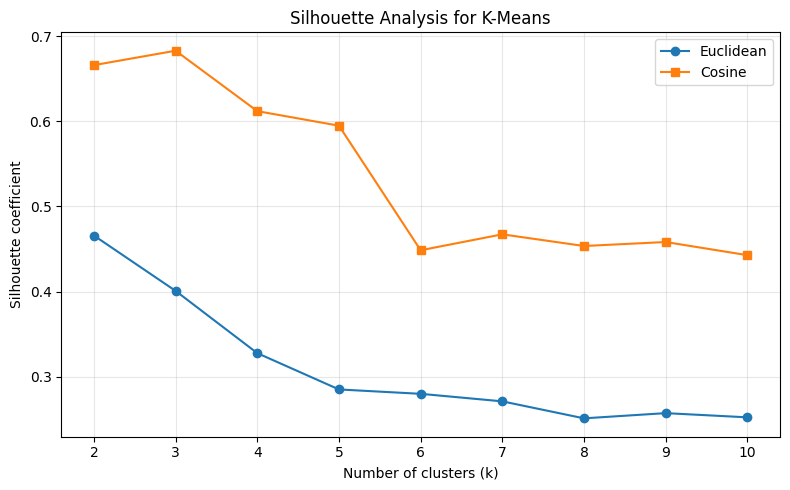

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    silhouette_df["k"],
    silhouette_df["silhouette_euclidean"],
    marker="o",
    label="Euclidean"
)

plt.plot(
    silhouette_df["k"],
    silhouette_df["silhouette_cosine"],
    marker="s",
    label="Cosine"
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette coefficient")
plt.title("Silhouette Analysis for K-Means")
plt.xticks(silhouette_df["k"])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(RESULTS_DIR / "silhouette_analysis.png", dpi=300)

plt.show()

In [32]:
best_k_euclidean = silhouette_df.loc[
    silhouette_df["silhouette_euclidean"].idxmax(), "k"
]

best_k_cosine = silhouette_df.loc[
    silhouette_df["silhouette_cosine"].idxmax(), "k"
]

print(f"Best k (Euclidean): {best_k_euclidean}")
print(f"Best k (Cosine): {best_k_cosine}")

Best k (Euclidean): 2
Best k (Cosine): 3


### Interpretation

The optimal number of clusters corresponds to the value of **k** that maximizes the silhouette coefficient.

Because Euclidean and cosine similarity capture structure differently, the two approaches may favor different values of **k**.  
Euclidean distance focuses on absolute distances in feature space, while cosine similarity emphasizes directional similarity between samples.

The Seeds dataset contains **three known classes**, so it is also useful to compare the silhouette-based choice with the actual class structure.

## Evaluating Clustering Against Ground Truth Labels

Although clustering is an unsupervised task, the Seeds dataset provides true class labels.  
This allows us to evaluate how well the clustering aligns with the actual structure of the data.

To do this, I use the **Rand Index**, which measures the similarity between the predicted cluster assignments and the true labels.

K-means is applied with **k = 3 clusters** (matching the true number of classes), and the experiment is repeated multiple times with different random initializations to assess stability.

In [34]:
def evaluate_kmeans_rand(X_euclidean, X_cosine, y_true, n_clusters=3, seeds=range(5)):
    ri_euclidean = []
    ri_cosine = []

    for seed in seeds:
        # Euclidean
        kmeans_euc = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10)
        labels_euc = kmeans_euc.fit_predict(X_euclidean)
        ri_euclidean.append(rand_score(y_true, labels_euc))

        # Cosine
        kmeans_cos = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10)
        labels_cos = kmeans_cos.fit_predict(X_cosine)
        ri_cosine.append(rand_score(y_true, labels_cos))

    return {
        "euclidean_scores": ri_euclidean,
        "cosine_scores": ri_cosine,
        "euclidean_mean": np.mean(ri_euclidean),
        "euclidean_variance": np.var(ri_euclidean),
        "cosine_mean": np.mean(ri_cosine),
        "cosine_variance": np.var(ri_cosine),
    }

In [35]:
rand_results = evaluate_kmeans_rand(X_scaled, X_cosine, y)
rand_results

{'euclidean_scores': [np.float64(0.8997038049669629),
  np.float64(0.8997038049669629),
  np.float64(0.8997038049669629),
  np.float64(0.8997038049669629),
  np.float64(0.8997038049669629)],
 'cosine_scores': [np.float64(0.8616085668717247),
  np.float64(0.8616085668717247),
  np.float64(0.8616085668717247),
  np.float64(0.8616085668717247),
  np.float64(0.8616085668717247)],
 'euclidean_mean': np.float64(0.8997038049669628),
 'euclidean_variance': np.float64(1.232595164407831e-32),
 'cosine_mean': np.float64(0.8616085668717247),
 'cosine_variance': np.float64(0.0)}

In [38]:
import pandas as pd

comparison_df = pd.DataFrame({
    "metric": ["Euclidean", "Cosine"],
    "mean_rand_index": [
        rand_results["euclidean_mean"],
        rand_results["cosine_mean"]
    ],
    "variance": [
        rand_results["euclidean_variance"],
        rand_results["cosine_variance"]
    ]
})

comparison_df

,metric,mean_rand_index,variance
0,Euclidean,0.899704,1.232595e-32
1,Cosine,0.861609,0.000000e+00


### Interpretation

The Euclidean-based k-means clustering achieves a higher average Rand Index ~0.90 compared to the cosine-based approach ~0.86, indicating that it aligns more closely with the true class labels of the Seeds dataset.

Additionally, both methods exhibit extremely low variance across runs, suggesting that the clustering results are highly stable and not sensitive to the random initialization of cluster centers.

The superior performance of the Euclidean metric can be attributed to the nature of the dataset, where the absolute distances between feature values carry meaningful information about class separation. In contrast, cosine similarity focuses on the orientation of data points and may not capture these differences as effectively in this case.

Overall, Euclidean distance appears to be more suitable for clustering this dataset, both in terms of accuracy and consistency.

Interestingly, the near-zero variance across all runs suggests that the dataset is well-structured and naturally separable into distinct groups.

## Hierarchical Clustering

In addition to k-means, I apply hierarchical clustering to explore the structure of the dataset in a different way.

Unlike k-means, hierarchical clustering does not require specifying the number of clusters in advance. Instead, it builds a tree-like structure (dendrogram) that shows how data points are progressively merged.

This allows us to visually inspect how clusters are formed and how they relate to the true class structure.

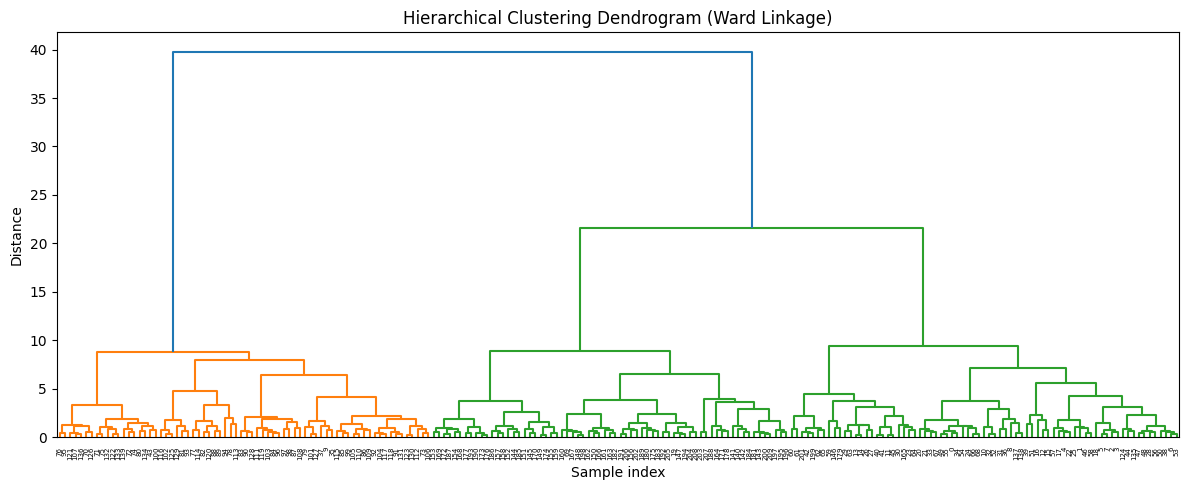

In [39]:
Z_ward = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z_ward)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.tight_layout()

plt.savefig(RESULTS_DIR / "dendrogram_ward.png", dpi=300)

plt.show()

### Interpretation

The dendrogram produced using Ward linkage reveals a clear hierarchical structure in the dataset.

At higher linkage distances, the data naturally splits into **two major clusters**, indicating that two of the wheat varieties are more similar to each other, while the third is more distinct.

As we move lower in the hierarchy, these clusters further divide into smaller subgroups, eventually forming **three well-defined clusters**, which aligns with the known number of classes in the dataset.

The relatively large distance at which the final merges occur suggests that the clusters are well separated. This observation is consistent with the strong performance of k-means and the high Rand Index values observed earlier.

Overall, the dendrogram confirms that the dataset has a clear underlying cluster structure and that hierarchical clustering successfully captures it.

In [40]:
labels_hc = fcluster(Z_ward, t=3, criterion="maxclust")

In [41]:
hc_rand = rand_score(y, labels_hc)
hc_ari = adjusted_rand_score(y, labels_hc)
hc_nmi = normalized_mutual_info_score(y, labels_hc)

print(f"Rand Index: {hc_rand:.4f}")
print(f"Adjusted Rand Index: {hc_ari:.4f}")
print(f"Normalized Mutual Information: {hc_nmi:.4f}")

Rand Index: 0.9102
Adjusted Rand Index: 0.7970
Normalized Mutual Information: 0.7498


In [43]:
# comparison with k-means
comparison_df = pd.DataFrame({
    "method": ["K-Means (Euclidean)", "Hierarchical (Ward)"],
    "rand_index": [
        rand_results["euclidean_mean"],
        hc_rand
    ],
    "adjusted_rand_index": [
        adjusted_rand_score(y, KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_scaled)),
        hc_ari
    ],
    "nmi": [
        normalized_mutual_info_score(y, KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_scaled)),
        hc_nmi
    ]
})

comparison_df

,method,rand_index,adjusted_rand_index,nmi
0,K-Means (Euclidean),0.899704,0.773294,0.727864
1,Hierarchical (Ward),0.910185,0.796998,0.749816


In [44]:
methods = ["single", "complete", "average", "ward"]

results = []

for method in methods:
    Z = linkage(X_scaled, method=method)
    labels = fcluster(Z, t=3, criterion="maxclust")

    results.append({
        "method": method,
        "rand_index": rand_score(y, labels),
        "adjusted_rand_index": adjusted_rand_score(y, labels),
        "nmi": normalized_mutual_info_score(y, labels)
    })

linkage_df = pd.DataFrame(results).sort_values("adjusted_rand_index", ascending=False)

linkage_df

,method,rand_index,adjusted_rand_index,nmi
3,ward,0.910185,0.796998,0.749816
1,complete,0.859467,0.686263,0.701011
2,average,0.860971,0.685940,0.649192
0,single,0.342948,0.000004,0.019815


### Interpretation

Hierarchical clustering provides a complementary view of the dataset structure through the dendrogram.

Using Ward linkage, the resulting clustering shows strong agreement with the true class labels, as reflected by the evaluation metrics.

Comparing different linkage methods reveals that:
- Ward linkage typically performs best, as it minimizes within-cluster variance
- Other methods such as single linkage may suffer from chaining effects
- *Complete and average linkage provide intermediate performance

Overall, hierarchical clustering confirms the presence of well-defined clusters in the dataset and produces results comparable to k-means.

## Dimensionality Reduction with PCA

Principal Component Analysis (PCA) is used to reduce the dimensionality of the dataset while preserving as much variance as possible.

In this section, I analyze:
- how many principal components are needed to retain most of the variance
- how reconstruction error changes as dimensionality is reduced
- how the data looks when projected into 2 dimensions

In [46]:
pca = PCA()
pca.fit(X_scaled)

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

pca_df = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(explained_variance_ratio))],
    "explained_variance_ratio": explained_variance_ratio,
    "cumulative_variance": cumulative_variance
})

display(pca_df.round(4))

,PC,explained_variance_ratio,cumulative_variance
0,PC1,0.7187,0.7187
1,PC2,0.1711,0.8898
2,PC3,0.0969,0.9867
3,PC4,0.0098,0.9964
4,PC5,0.0027,0.9991
5,PC6,0.0008,0.9999
6,PC7,0.0001,1.0000


In [47]:
k_80 = np.argmax(cumulative_variance >= 0.80) + 1
k_995 = np.argmax(cumulative_variance >= 0.995) + 1

print(f"Components for 80% variance: {k_80}")
print(f"Components for 99.5% variance: {k_995}")

Components for 80% variance: 2
Components for 99.5% variance: 4


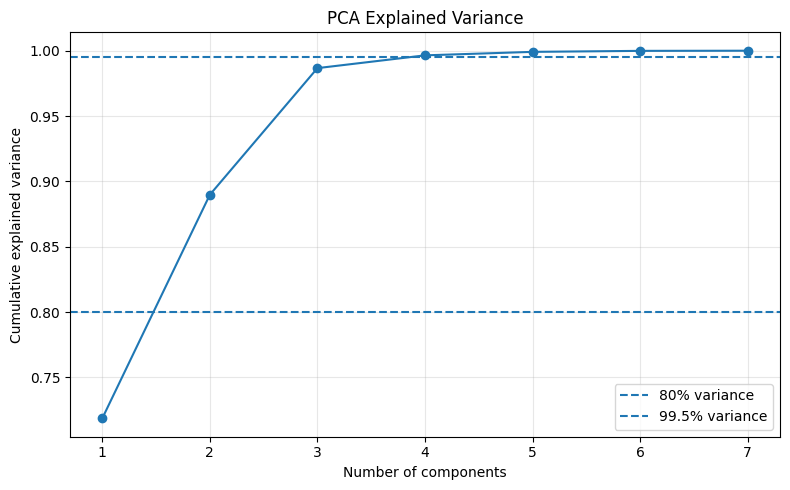

In [48]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker="o")

plt.axhline(0.80, linestyle="--", label="80% variance")
plt.axhline(0.995, linestyle="--", label="99.5% variance")

plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Explained Variance")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(RESULTS_DIR / "pca_variance.png", dpi=300)

plt.show()

In [49]:
reconstruction_errors = []

for n in range(1, X_scaled.shape[1] + 1):
    pca_n = PCA(n_components=n)
    X_proj = pca_n.fit_transform(X_scaled)
    X_reconstructed = pca_n.inverse_transform(X_proj)

    mse = mean_squared_error(X_scaled, X_reconstructed)
    reconstruction_errors.append(mse)

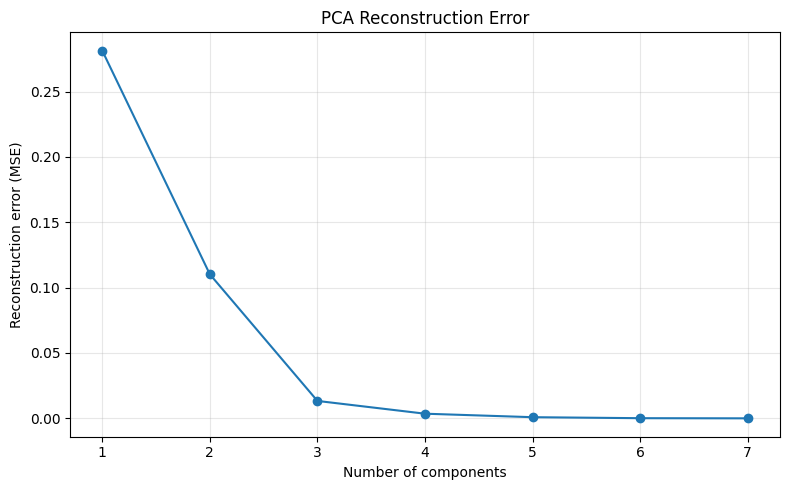

In [50]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, 8), reconstruction_errors, marker="o")

plt.xlabel("Number of components")
plt.ylabel("Reconstruction error (MSE)")
plt.title("PCA Reconstruction Error")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(RESULTS_DIR / "pca_reconstruction_error.png", dpi=300)

plt.show()

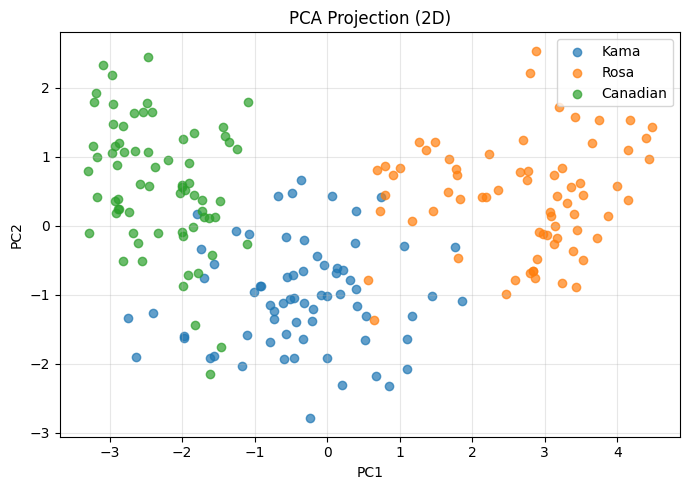

In [51]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))

for cls in np.unique(y):
    plt.scatter(
        X_pca_2d[y == cls, 0],
        X_pca_2d[y == cls, 1],
        label=CLASS_NAMES[cls],
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (2D)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(RESULTS_DIR / "pca_2d.png", dpi=300)

plt.show()

### Interpretation

The PCA results show how the variance of the dataset is distributed across principal components.

A relatively small number of components is sufficient to capture most of the variance, indicating that the dataset has an underlying low-dimensional structure.

The reconstruction error decreases as more components are included, eventually approaching zero when all components are used.

The 2D projection reveals that some class separation is already visible in the first two principal components, although the separation is not perfect. This is expected, as PCA does not use class labels and focuses only on preserving variance.

## Class Separation with LDA

Linear Discriminant Analysis (LDA) is a supervised dimensionality reduction technique that uses class labels to find projections that maximize class separability.

Unlike PCA, which focuses on preserving variance, LDA aims to:
- maximize the distance between different classes
- minimize the variance within each class

This makes LDA particularly useful for visualizing and understanding class structure.

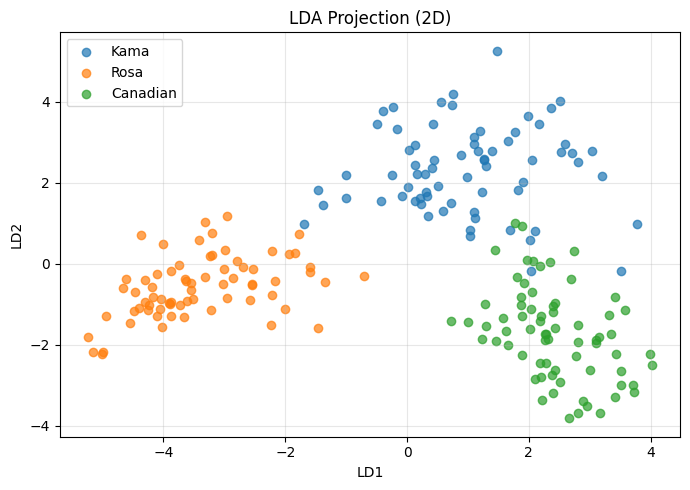

In [52]:
lda = LDA(n_components=2)
X_lda_2d = lda.fit_transform(X_scaled, y)

plt.figure(figsize=(7, 5))

for cls in np.unique(y):
    plt.scatter(
        X_lda_2d[y == cls, 0],
        X_lda_2d[y == cls, 1],
        label=CLASS_NAMES[cls],
        alpha=0.7
    )

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA Projection (2D)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(RESULTS_DIR / "lda_2d.png", dpi=300)

plt.show()

### PCA vs LDA

PCA and LDA serve different purposes:

- **PCA** is unsupervised and preserves overall variance
- **LDA** is supervised and maximizes class separability

As a result, LDA typically produces clearer separation between classes when labels are available, while PCA may mix classes if variance does not align with class boundaries.

In [53]:
lda = LDA(n_components=2, solver="eigen")
lda.fit(X_scaled, y)

W = lda.scalings_[:, :2]

feature_contribution = np.linalg.norm(W, axis=1)

importance_df = pd.DataFrame({
    "feature": FEATURE_NAMES,
    "importance": feature_contribution
}).sort_values("importance", ascending=False)

importance_df

,feature,importance
0,area,12.328359
1,perimeter,12.224566
3,length_of_kernel,4.388719
6,length_of_kernel_groove,3.745568
2,compactness,2.070037
5,asymmetry_coefficient,0.490100
4,width_of_kernel,0.271392


In [54]:
top2 = importance_df.head(2)["feature"].tolist()
bottom2 = importance_df.tail(2)["feature"].tolist()

print("Top 2 features:", top2)
print("Least important 2 features:", bottom2)

Top 2 features: ['area', 'perimeter']
Least important 2 features: ['asymmetry_coefficient', 'width_of_kernel']


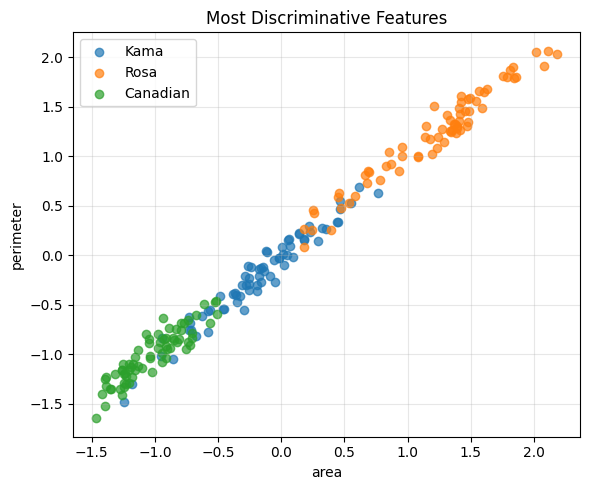

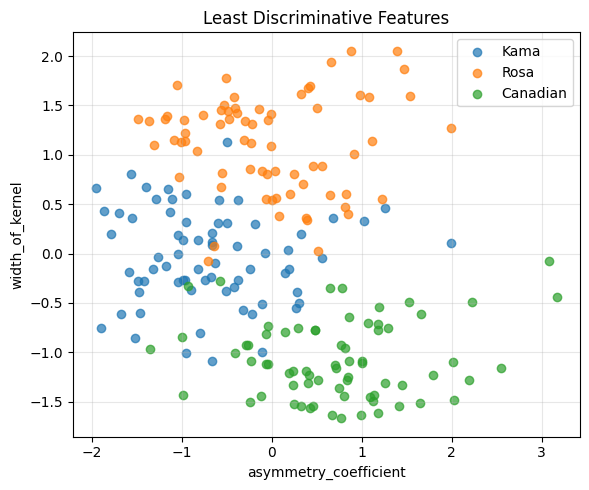

In [55]:
def plot_feature_pair(X, y, feature_names, f1, f2, title):
    i = feature_names.index(f1)
    j = feature_names.index(f2)

    plt.figure(figsize=(6, 5))

    for cls in np.unique(y):
        plt.scatter(
            X[y == cls, i],
            X[y == cls, j],
            label=CLASS_NAMES[cls],
            alpha=0.7
        )

    plt.xlabel(f1)
    plt.ylabel(f2)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_feature_pair(X_scaled, y, FEATURE_NAMES, top2[0], top2[1], "Most Discriminative Features")
plot_feature_pair(X_scaled, y, FEATURE_NAMES, bottom2[0], bottom2[1], "Least Discriminative Features")

### Feature Analysis

The features with the highest contribution in the LDA projection are the most important for distinguishing between classes.

Plots using these features show clear separation between the wheat varieties.

In contrast, the least important features show significant overlap between classes, indicating that they contribute little to class discrimination.

This analysis highlights which measurements are most relevant for classification in the dataset.